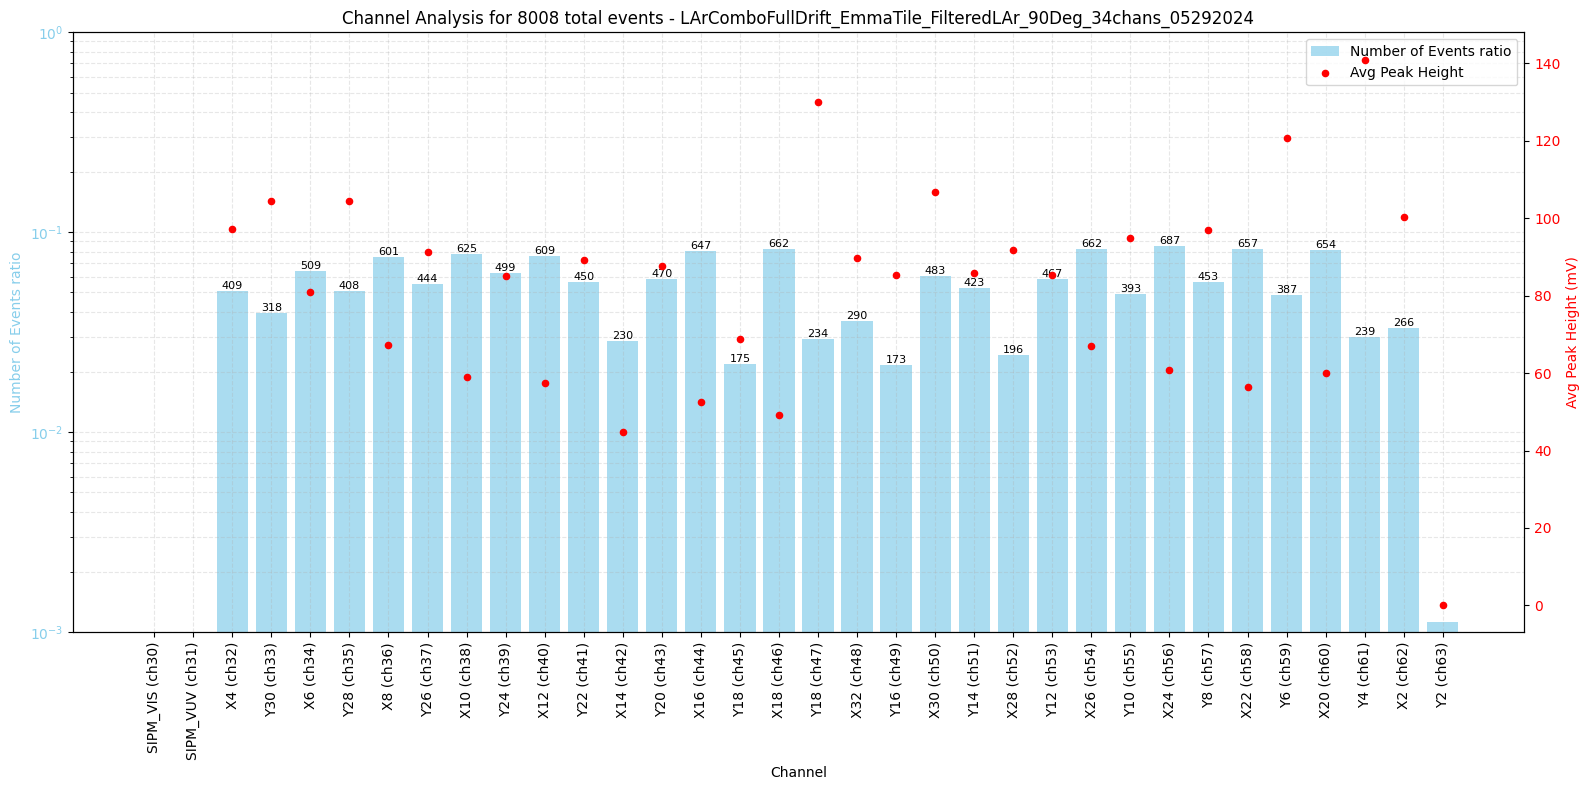

In [22]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# total number of events from this dataset
Nbevent = 8008
# Load data
file_path = '/home/jiancheng/NAS/LAr_TPC_runs/Run19/jon/EmmasTile/LAr/Filtered/LArComboFullDrift_EmmaTile_FilteredLAr_90Deg_34chans_05292024/CSP_interesting_events_stats.csv'
df = pd.read_csv(file_path, header=None)
parent_dir = os.path.basename(os.path.dirname(file_path))

# Extract data
events_row = df[df[0] == 'number of interesting events'].iloc[0]
peak_sum_row = df[df[0] == 'peak sum'].iloc[0]
# Extract the raw channel names and descriptions
channel_names = df.iloc[0, 1:].values  # Skip first column if needed
# Get descriptions from second row (SiPM_VIS, B-SIG2, etc.)
channel_descriptions = df.iloc[1, 1:].values
# Combine in format: Description (ChannelName)
channels = [f"{desc} ({name})" for desc, name in zip(channel_descriptions, channel_names)]

# Convert to numeric
events_data = pd.to_numeric(events_row[1:], errors='coerce').fillna(0)
peak_sum_data = pd.to_numeric(peak_sum_row[1:], errors='coerce').fillna(0)

# Calculate average peak (safe division)
with np.errstate(divide='ignore', invalid='ignore'):
    avg_peak = np.where(events_data > 0, peak_sum_data/events_data, np.nan)

# Create plot with proper x-axis indexing
fig, ax1 = plt.subplots(figsize=(16, 8))
x = np.arange(len(channels))  # Create numeric x-axis positions

# Bar plot (events)
bars = ax1.bar(x, events_data/Nbevent, color='skyblue', alpha=0.7, width=0.8, label='Number of Events ratio')
ax1.set_xlabel('Channel')
ax1.set_ylabel('Number of Events ratio', color='skyblue')
ax1.tick_params(axis='y', labelcolor='skyblue')
ax1.set_xticks(x)
ax1.set_xticklabels(channels, rotation=90)
# Set y-axis to logarithmic scale and range
ax1.set_yscale('log')
ax1.set_ylim(1e-3, 1)

# Scatter plot (average peaks)
ax2 = ax1.twinx()
scatter = ax2.scatter(x, avg_peak, color='red', s=20, label='Avg Peak Height', zorder=3)
ax2.set_ylabel('Avg Peak Height (mV)', color='red')
ax2.tick_params(axis='y', labelcolor='red')

# Add value labels to bars
for i, bar in enumerate(bars):
    height = bar.get_height()
    if height > 0.01:
        ax1.text(bar.get_x() + bar.get_width()/2, height,
                f'{int(height * Nbevent)}',
                ha='center', va='bottom', fontsize=8)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper right')
ax1.grid(which="both", ls="--", alpha=0.3)

plt.title(f"Channel Analysis for {Nbevent} total events - {parent_dir}")
plt.tight_layout()
plt.show()